In [25]:
from accelforge import Spec, examples
from pathlib import Path

In [26]:
def get_energy(result):
    """Get total energy in pJ."""
    return float(result.energy())


def get_cycles(result):
    """Get total latency in cycles."""
    return float(result.latency())


def get_component_energy(result, component):
    """Get energy for a specific component."""
    energy = result.energy(per_component=True)
    return float(energy.get(component, 0))

def get_component_cycles(result, component):
    """Get energy for a specific component."""
    latency = result.latency(per_component=True)
    return float(latency.get(component, 0))

# Pure Accelforge Run

In [27]:
# spec = Spec.from_yaml(
#     "../arches/tpu_v4i_with_VPU.yaml",
#     "../workloads/C_4/flash_attention_C_4.yaml"
# )
# results = spec.map_workload_to_arch()

In [28]:
# results

In [29]:
# print("Total Cycles: ", get_cycles(results))
# print("Total Energy: ", get_energy(results))
# print("MainMemory: ", get_component_energy(results, 'MainMemory'))
# print("GlobalBuffer: ", get_component_energy(results, 'GlobalBuffer'))
# print()
# print("ScalarBuffer: ", get_component_energy(results, 'ScalarBuffer'))
# print("ScalarUnit: ", get_component_energy(results, 'ScalarUnit'))
# print()
# print("VpuBuffer: ", get_component_energy(results, 'VpuBuffer'))
# print("VPU: ", get_component_energy(results, 'VPU'))
# print()
# print("MxuBuffer: ", get_component_energy(results, 'MxuBuffer'))
# print("MXU: ", get_component_energy(results, 'MXU'))

# P = 1

In [30]:
# QK
P_1_QK_spec = Spec.from_yaml(
    "../arches/tpu_v4i_with_VPU_QK.yaml",
    "../workloads/C_2_MR/flash_attention_C_2_QK.yaml"
)
P_1_QK_results = P_1_QK_spec.map_workload_to_arch()

Getting energy, latency, and leak power for compone
Generating jobs:   0%|       | 0/1 [00:00<?, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum QK_1: 0it [00:00, ?it/s]

Generating pmapping templates for compute MXU Einsum QK_1: 0it [00:00, ?it/s]
Generating pmapping templates for compute MXU Einsum QK_1: 10it [00:00, 94.78it/s]
Generating pmapping templates for compute MXU Einsum QK_1: 20it [00:00, 90.23it/s]
Generating pmapping templates for compute MXU Einsum QK_1: 32it [00:00, 89.43it/s]
Generating jobs: 100%|█| 1/1 [00:00<00:00,  2.38it/


Einsum QK_1 has 32 pmapping jobs:
	0	[QK_1 in MainMemory] [Q in MainMemory] [K_1 in MainMemory] T-b  T-e  T-h  T-m_chunk  S-reuse_weight2-e  S-reuse_weight1-m_chunk  [K_1 in MxuBuffer] T-m  [QK_1 in MxuBuffer] T-e  MXU computes QK_1
	1	[QK_1 in MainMemory] [Q in MainMemory] [K_1 in MainMemory] T-b  T-h  T-m  T-m_chunk  S-reuse_weight2-e  S-reuse_weight1-m_chunk  [QK_1 in MxuBuffer] T-e  [K_1 in MxuBuffer] T-m  MXU computes QK_1
	2	[QK_1 in MainMemory] [Q in MainMemory] [K_1 in MainMemory] T-b  T-e  T-h  T-m_chunk  [K_1 in GlobalBuffer] S-reuse_weight2-e  S-reuse_weight1-m_chunk  [K_1 in MxuBuffer] T-m  [QK_1 in MxuBuffer] T-e  MXU computes QK_1
	3	[QK_1 in MainMemory] [Q in MainMemory] [K_1 in MainMemory] T-b  T-e  T-h  T-m_chunk  [K_1 in GlobalBuffer] T-m  S-reuse_weight2-e  S-reuse_weight1-m_chunk  [QK_1 in MxuBuffer] T-e  [K_1 in MxuBuffer] T-m  MXU computes QK_1
	4	[QK_1 in MainMemory] [Q in MainMemory] [K_1 in MainMemory] T-b  T-e  T-h  T-m  [Q in GlobalBuffer] T-m_chunk  S-reuse_

Generating pmappings: 100%|█| 32/32 [00:19<00:00,  
Grouping pmappings for QK_1: 100%|█| 1/1 [00:00<00:
Compressing pmappings: 100%|█| 1/1 [00:00<00:00, 21


Dirty joining with resource usage <= 1.02× optimal
Dirty joining with objectives <= 2× optimal


Dirty pruning pmappings: 100%|█| 1/1 [00:00<00:00, 


...

Filtering out pmappings worse than the following:
	Total<SEP>energy=4.40e-03
Final clean join.


Dirty pruning pmappings: 100%|█| 1/1 [00:00<00:00, 


Dirty joining uses 100.00% of the pmappings
Filtered 1 -> 1 (100.00% kept) pmappings


Final consolidate: 100%|█| 1/1 [00:00<00:00, 7358.4


Dirty joining mapping(s) valid & optimal! Returning...


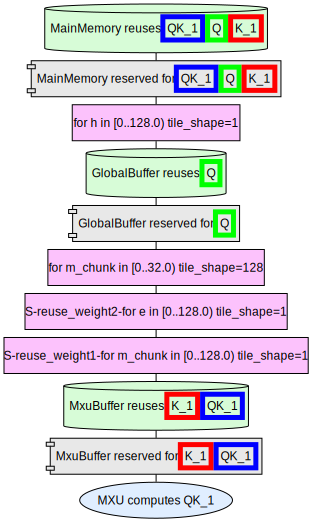

In [31]:
# QK
P_1_QK_results

In [32]:
# QK
print("Total Cycles: ", get_cycles(P_1_QK_results))
print("Total Energy: ", get_energy(P_1_QK_results))
print("MainMemory: ", get_component_energy(P_1_QK_results, 'MainMemory'))
print("GlobalBuffer: ", get_component_energy(P_1_QK_results, 'GlobalBuffer'))
print()
print("ScalarBuffer: ", get_component_energy(P_1_QK_results, 'ScalarBuffer'))
print("ScalarUnit: ", get_component_energy(P_1_QK_results, 'ScalarUnit'))
print()
print("VpuBuffer: ", get_component_energy(P_1_QK_results, 'VpuBuffer'))
print("VPU: ", get_component_energy(P_1_QK_results, 'VPU'))
print()
print("MxuBuffer: ", get_component_energy(P_1_QK_results, 'MxuBuffer'))
print("MXU: ", get_component_energy(P_1_QK_results, 'MXU'))

Total Cycles:  0.00011017840006388724
Total Energy:  0.00440040966177228
MainMemory:  0.003804609877988696
GlobalBuffer:  8.194621439900847e-06

ScalarBuffer:  0.0
ScalarUnit:  0.0

VpuBuffer:  0.0
VPU:  0.0

MxuBuffer:  0.0005819680743837287
MXU:  5.637144576e-06


In [33]:
# SM
P_1_SM_spec = Spec.from_yaml(
    "../arches/tpu_v4i_with_VPU.yaml",
    "../workloads/C_2_MR/flash_attention_C_2_SM.yaml"
)
P_1_SM_results = P_1_SM_spec.map_workload_to_arch()

Getting energy, latency, and leak power for compone
Generating pmapping templates for compute ScalarUnit Einsum max_1: 10it [00:00, 72.96it/s]/s]
Generating pmapping templates for compute MXU Einsum max_1: 0it [00:00, ?it/s]
Generating pmapping templates for compute VPU Einsum max_1: 0it [00:00, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum exp_1: 16it [00:00, 68.42it/s]
Generating pmapping templates for compute ScalarUnit Einsum sum_1: 16it [00:00, 66.08it/s]
Generating pmapping templates for compute ScalarUnit Einsum softmax_1: 16it [00:00, 62.68it/s]
Generating pmapping templates for compute MXU Einsum exp_1: 0it [00:00, ?it/s]t/s]
Generating pmapping templates for compute MXU Einsum sum_1: 0it [00:00, ?it/s]
Generating pmapping templates for compute MXU Einsum softmax_1: 0it [00:00, ?it/s]
Generating pmapping templates for compute VPU Einsum exp_1: 0it [00:00, ?it/s]t/s]
Generating pmapping templates for compute VPU Einsum sum_1: 0it [00:00, ?it/s]
Generating p

Einsum max_1 has 10 pmapping jobs:
	0	[max_1 in MainMemory] [QK_1 in MainMemory] T-b  T-h  T-m  T-m_chunk  S-Z-m_chunk  S-Z-m  S-Z-h  S-Z-b  [QK_1 in ScalarBuffer] [max_1 in ScalarBuffer] T-m_chunk  ScalarUnit computes max_1
	1	[max_1 in MainMemory] [QK_1 in MainMemory] T-b  T-h  T-m  S-Z-m_chunk  S-Z-m  S-Z-h  S-Z-b  [max_1 in ScalarBuffer] T-m_chunk  [QK_1 in ScalarBuffer] ScalarUnit computes max_1
	2	[max_1 in MainMemory] [QK_1 in MainMemory] T-b  T-h  T-m  T-m_chunk  [QK_1 in GlobalBuffer] S-Z-m_chunk  S-Z-m  S-Z-h  S-Z-b  [QK_1 in ScalarBuffer] [max_1 in ScalarBuffer] T-m_chunk  ScalarUnit computes max_1
	3	[max_1 in MainMemory] [QK_1 in MainMemory] T-b  T-h  T-m  T-m_chunk  [QK_1 in GlobalBuffer] S-Z-m_chunk  S-Z-m  S-Z-h  S-Z-b  [max_1 in ScalarBuffer] T-m_chunk  [QK_1 in ScalarBuffer] ScalarUnit computes max_1
	4	[max_1 in MainMemory] [QK_1 in MainMemory] T-b  T-h  T-m  [max_1 in GlobalBuffer] T-m_chunk  S-Z-m_chunk  S-Z-m  S-Z-h  S-Z-b  [QK_1 in ScalarBuffer] [max_1 in ScalarB

Generating pmappings: 100%|█| 58/58 [00:06<00:00,  
Grouping pmappings for max_1: 100%|█| 1/1 [00:00<00
Grouping pmappings for exp_1: 100%|█| 5/5 [00:00<00
Grouping pmappings for sum_1: 100%|█| 6/6 [00:00<00
Grouping pmappings for softmax_1: 100%|█| 5/5 [00:0
Compressing pmappings: 100%|█| 4/4 [00:00<00:00, 10


Dirty joining with resource usage <= 1.02× optimal
Dirty joining with objectives <= 2× optimal


Dirty pruning pmappings: 100%|█| 17/17 [00:00<00:00


...

Dirty pruning pmappings: 100%|█| 17/17 [00:00<00:00


Dirty joining uses 100.00% of the pmappings
Filtered 288 -> 288 (100.00% kept) pmappings


Joining pmappings for max_1 <--> exp_1 (2/4): 100%|
Joining pmappings for exp_1 <--> sum_1 (3/4): 100%|
Joining pmappings for sum_1 <--> softmax_1 (4/4): 1
Final consolidate: 100%|█| 6/6 [00:00<00:00, 220.98


Dirty joining mapping(s) valid & optimal! Returning...


/Users/mayarebholz/6.5930/accelforge/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:368: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


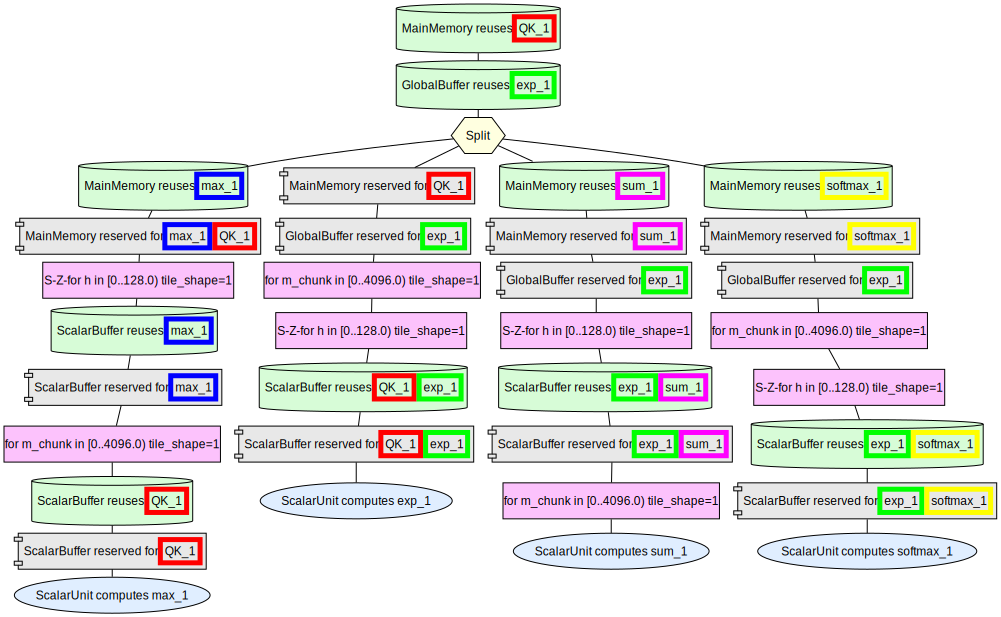

In [34]:
# SM
P_1_SM_results

In [35]:
# SM
print("Total Cycles: ", get_cycles(P_1_SM_results))
print("Total Energy: ", get_energy(P_1_SM_results))
print("MainMemory: ", get_component_energy(P_1_SM_results, 'MainMemory'))
print("GlobalBuffer: ", get_component_energy(P_1_SM_results, 'GlobalBuffer'))
print()
print("ScalarBuffer: ", get_component_energy(P_1_SM_results, 'ScalarBuffer'))
print("ScalarUnit: ", get_component_energy(P_1_SM_results, 'ScalarUnit'))
print()
print("VpuBuffer: ", get_component_energy(P_1_SM_results, 'VpuBuffer'))
print("VPU: ", get_component_energy(P_1_SM_results, 'VPU'))
print()
print("MxuBuffer: ", get_component_energy(P_1_SM_results, 'MxuBuffer'))
print("MXU: ", get_component_energy(P_1_SM_results, 'MXU'))

Total Cycles:  1.5603809515596367e-05
Total Energy:  0.00013484449258408302
MainMemory:  8.847226770392069e-05
GlobalBuffer:  2.5669140995887574e-05

ScalarBuffer:  1.8186502324491517e-05
ScalarUnit:  2.5165824e-06

VpuBuffer:  0.0
VPU:  0.0

MxuBuffer:  0.0
MXU:  0.0


In [36]:
# AV
P_1_AV_spec = Spec.from_yaml(
    "../arches/tpu_v4i_with_VPU_AV.yaml",
    "../workloads/C_2_MR/flash_attention_C_2_AV.yaml"
)
P_1_AV_results = P_1_AV_spec.map_workload_to_arch()

Getting energy, latency, and leak power for compone
Generating jobs:   0%|       | 0/1 [00:00<?, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum AV_1: 0it [00:00, ?it/s]

Generating pmapping templates for compute MXU Einsum AV_1: 0it [00:00, ?it/s]
Generating pmapping templates for compute MXU Einsum AV_1: 6it [00:00, 54.27it/s]
Generating pmapping templates for compute MXU Einsum AV_1: 12it [00:00, 47.11it/s]
Generating pmapping templates for compute MXU Einsum AV_1: 17it [00:00, 43.63it/s]
Generating pmapping templates for compute MXU Einsum AV_1: 22it [00:00, 42.72it/s]
Generating pmapping templates for compute MXU Einsum AV_1: 27it [00:00, 43.05it/s]
Generating pmapping templates for compute MXU Einsum AV_1: 32it [00:00, 42.05it/s]

Generating pmapping templates for compute VPU Einsum AV_1: 0it [00:00, ?it/s]
Generating pmapping templates for compute VPU Einsum AV_1: 2it [00:00, 11.56it/s]
Generating pmapping templates for compute VPU Einsum AV_1: 4it [00:00, 10.

Einsum AV_1 has 64 pmapping jobs:
	0	[softmax_1 in MainMemory] [V_1 in MainMemory] [AV_1 in MainMemory] T-b  T-e  T-h  T-m  S-reuse_weight2-m_chunk  S-reuse_weight1-e  [AV_1 in MxuBuffer] T-m_chunk  [V_1 in MxuBuffer] T-m  MXU computes AV_1
	1	[softmax_1 in MainMemory] [V_1 in MainMemory] [AV_1 in MainMemory] T-b  T-e  T-h  T-m_chunk  S-reuse_weight2-m_chunk  S-reuse_weight1-e  [V_1 in MxuBuffer] T-m  [AV_1 in MxuBuffer] T-m_chunk  MXU computes AV_1
	2	[softmax_1 in MainMemory] [V_1 in MainMemory] [AV_1 in MainMemory] T-b  T-e  T-h  T-m  [AV_1 in GlobalBuffer] S-reuse_weight2-m_chunk  S-reuse_weight1-e  [AV_1 in MxuBuffer] T-m_chunk  [V_1 in MxuBuffer] T-m  MXU computes AV_1
	3	[softmax_1 in MainMemory] [V_1 in MainMemory] [AV_1 in MainMemory] T-b  T-e  T-h  T-m  [AV_1 in GlobalBuffer] T-m_chunk  S-reuse_weight2-m_chunk  S-reuse_weight1-e  [V_1 in MxuBuffer] T-m  [AV_1 in MxuBuffer] T-m_chunk  MXU computes AV_1
	4	[softmax_1 in MainMemory] [V_1 in MainMemory] [AV_1 in MainMemory] T-b  

Generating pmappings: 100%|█| 64/64 [00:15<00:00,  
Grouping pmappings for AV_1: 100%|█| 1/1 [00:00<00:
Compressing pmappings: 100%|█| 1/1 [00:00<00:00, 23


Dirty joining with resource usage <= 1.02× optimal
Dirty joining with objectives <= 2× optimal


Dirty pruning pmappings: 100%|█| 1/1 [00:00<00:00, 


...

Filtering out pmappings worse than the following:
	Total<SEP>energy=4.39e-03
Final clean join.


Dirty pruning pmappings: 100%|█| 1/1 [00:00<00:00, 


Dirty joining uses 100.00% of the pmappings
Filtered 1 -> 1 (100.00% kept) pmappings


Final consolidate: 100%|█| 1/1 [00:00<00:00, 6492.7


Dirty joining mapping(s) valid & optimal! Returning...


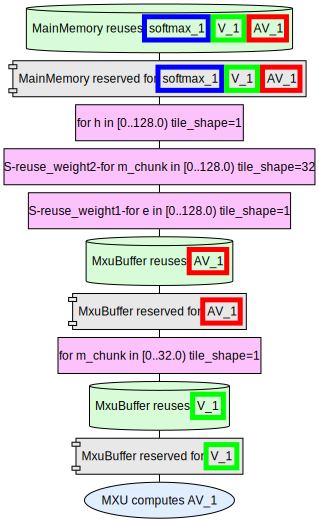

In [37]:
# AV
P_1_AV_results

In [38]:
# AV
print("Total Cycles: ", get_cycles(P_1_AV_results))
print("Total Energy: ", get_energy(P_1_AV_results))
print("MainMemory: ", get_component_energy(P_1_AV_results, 'MainMemory'))
print("MainMemory cycles: ", get_component_cycles(P_1_AV_results, 'MainMemory'))

print("GlobalBuffer: ", get_component_energy(P_1_AV_results, 'GlobalBuffer'))
print()
print("ScalarBuffer: ", get_component_energy(P_1_AV_results, 'ScalarBuffer'))
print("ScalarUnit: ", get_component_energy(P_1_AV_results, 'ScalarUnit'))
print()
print("VpuBuffer: ", get_component_energy(P_1_AV_results, 'VpuBuffer'))
print("VPU: ", get_component_energy(P_1_AV_results, 'VPU'))
print()
print("MxuBuffer: ", get_component_energy(P_1_AV_results, 'MxuBuffer'))
print("MXU: ", get_component_energy(P_1_AV_results, 'MXU'))
print("MXU cycles: ", get_component_cycles(P_1_AV_results, 'MXU'))


Total Cycles:  0.00011017840006388724
Total Energy:  0.004392215046662048
MainMemory:  0.0038046099295657265
MainMemory cycles:  0.00011017840006388724
GlobalBuffer:  0.0

ScalarBuffer:  0.0
ScalarUnit:  0.0

VpuBuffer:  0.0
VPU:  0.0

MxuBuffer:  0.0005819680889356439
MXU:  5.637144576e-06
MXU cycles:  3.900952378899092e-06


In [39]:
# ACC
P_1_ACC_spec = Spec.from_yaml(
    "../arches/tpu_v4i_only_VPU.yaml",
    "../workloads/C_2_MR/flash_attention_C_2_ACC.yaml"
)
P_1_ACC_results = P_1_ACC_spec.map_workload_to_arch()

Getting energy, latency, and leak power for compone
Generating jobs:   0%|       | 0/1 [00:00<?, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum AV_accum_1: 0it [00:00, ?it/s]

Generating pmapping templates for compute VPU Einsum AV_accum_1: 0it [00:00, ?it/s]
Generating pmapping templates for compute VPU Einsum AV_accum_1: 6it [00:00, 53.98it/s]
Generating pmapping templates for compute VPU Einsum AV_accum_1: 16it [00:00, 33.45it/s]
Generating jobs: 100%|█| 1/1 [00:00<00:00,  1.70it/


Einsum AV_accum_1 has 16 pmapping jobs:
	0	[AV_accum_1 in MainMemory] [AV_1 in MainMemory] [AV_0 in MainMemory] T-b  T-e  T-h  T-m  S-reuse_input-m  S-reuse_input-h  S-reuse_input-e  S-reuse_input-b  [AV_accum_1 in VpuBuffer] VPU computes AV_accum_1
	1	[AV_accum_1 in MainMemory] [AV_1 in MainMemory] [AV_0 in MainMemory] T-b  T-e  T-h  T-m  [AV_0 in GlobalBuffer] S-reuse_input-m  S-reuse_input-h  S-reuse_input-e  S-reuse_input-b  [AV_accum_1 in VpuBuffer] VPU computes AV_accum_1
	2	[AV_accum_1 in MainMemory] [AV_1 in MainMemory] [AV_0 in MainMemory] T-b  T-e  T-h  T-m  [AV_1 in GlobalBuffer] S-reuse_input-m  S-reuse_input-h  S-reuse_input-e  S-reuse_input-b  [AV_accum_1 in VpuBuffer] VPU computes AV_accum_1
	3	[AV_accum_1 in MainMemory] [AV_1 in MainMemory] [AV_0 in MainMemory] T-b  T-e  T-h  T-m  [AV_accum_1 in GlobalBuffer] S-reuse_input-m  S-reuse_input-h  S-reuse_input-e  S-reuse_input-b  [AV_accum_1 in VpuBuffer] VPU computes AV_accum_1
	4	[AV_accum_1 in MainMemory] [AV_1 in MainMe

Generating pmappings: 100%|█| 16/16 [00:00<00:00, 3
Grouping pmappings for AV_accum_1: 100%|█| 1/1 [00:
Compressing pmappings: 100%|█| 1/1 [00:00<00:00, 20


Dirty joining with resource usage <= 1.02× optimal
Dirty joining with objectives <= 2× optimal


Dirty pruning pmappings: 100%|█| 1/1 [00:00<00:00, 


...

Filtering out pmappings worse than the following:
	Total<SEP>energy=2.84e-06
Final clean join.


Dirty pruning pmappings: 100%|█| 1/1 [00:00<00:00, 


Dirty joining uses 100.00% of the pmappings
Filtered 1 -> 1 (100.00% kept) pmappings


Final consolidate: 100%|█| 1/1 [00:00<00:00, 1949.0


Dirty joining mapping(s) valid & optimal! Returning...


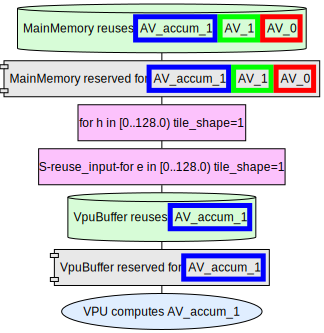

In [40]:
# ACC
P_1_ACC_results

In [41]:
# ACC
print("Total Cycles: ", get_cycles(P_1_ACC_results))
print("Total Energy: ", get_energy(P_1_ACC_results))
print("MainMemory: ", get_component_energy(P_1_ACC_results, 'MainMemory'))
print("GlobalBuffer: ", get_component_energy(P_1_ACC_results, 'GlobalBuffer'))
print()
print("ScalarBuffer: ", get_component_energy(P_1_ACC_results, 'ScalarBuffer'))
print("ScalarUnit: ", get_component_energy(P_1_ACC_results, 'ScalarUnit'))
print()
print("VpuBuffer: ", get_component_energy(P_1_ACC_results, 'VpuBuffer'))
print("VPU: ", get_component_energy(P_1_ACC_results, 'VPU'))
print()
print("MxuBuffer: ", get_component_energy(P_1_ACC_results, 'MxuBuffer'))
print("MXU: ", get_component_energy(P_1_ACC_results, 'MXU'))

Total Cycles:  1.2190476184059662e-07
Total Energy:  2.8405923653402333e-06
MainMemory:  2.7643084598335315e-06
GlobalBuffer:  0.0

ScalarBuffer:  0.0
ScalarUnit:  0.0

VpuBuffer:  7.104102905941545e-08
VPU:  5.24288e-09

MxuBuffer:  0.0
MXU:  0.0


In [42]:
# Gathered Results
print("QK Total Cycles: ", get_cycles(P_1_QK_results))
print("QK Total Energy: ", get_energy(P_1_QK_results))
print("SM Total Cycles: ", get_cycles(P_1_SM_results))
print("SM Total Energy: ", get_energy(P_1_SM_results))
print("AV Total Cycles: ", get_cycles(P_1_AV_results))
print("AV Total Energy: ", get_energy(P_1_AV_results))
print("ACC Total Cycles: ", get_cycles(P_1_ACC_results))
print("ACC Total Energy: ", get_energy(P_1_ACC_results))

QK Total Cycles:  0.00011017840006388724
QK Total Energy:  0.00440040966177228
SM Total Cycles:  1.5603809515596367e-05
SM Total Energy:  0.00013484449258408302
AV Total Cycles:  0.00011017840006388724
AV Total Energy:  0.004392215046662048
ACC Total Cycles:  1.2190476184059662e-07
ACC Total Energy:  2.8405923653402333e-06


In [43]:
# Total Pipeline Results
print("Total Pipeline Cycles: ", 2*(get_cycles(P_1_QK_results)+get_cycles(P_1_SM_results)+get_cycles(P_1_AV_results)+get_cycles(P_1_ACC_results)))
print("Total Pipeline Energy: ", 2*(get_energy(P_1_QK_results)+get_energy(P_1_SM_results)+get_energy(P_1_AV_results)+get_energy(P_1_ACC_results)))

Total Pipeline Cycles:  0.0004721650288104229
Total Pipeline Energy:  0.0178606195867675


# P = 2

In [44]:
# Total Pipeline Cycles
t0_cycles = get_cycles(P_1_QK_results)
t1_cycles = max(get_cycles(P_1_QK_results), get_cycles(P_1_SM_results))
t2_cycles = max(get_cycles(P_1_AV_results), get_cycles(P_1_SM_results))
t3_cycles = max(get_cycles(P_1_AV_results), get_cycles(P_1_ACC_results))
t8_cycles = get_cycles(P_1_ACC_results)

print("Total Pipeline Cycles: ", t0_cycles+t1_cycles+t2_cycles+t3_cycles+t8_cycles)

Total Pipeline Cycles:  0.00044083550501738955


In [45]:
# Total Pipeline Energy
t0_energy = get_energy(P_1_QK_results)
t1_energy = max(get_energy(P_1_QK_results), get_energy(P_1_SM_results))
t2_energy = max(get_energy(P_1_AV_results), get_energy(P_1_SM_results))
t3_energy = max(get_energy(P_1_AV_results), get_energy(P_1_ACC_results))
t8_energy = get_energy(P_1_ACC_results)

print("Total Pipeline Energy: ", t0_energy+t1_energy+t2_energy+t3_energy+t8_energy)

Total Pipeline Energy:  0.017588090009233996


# P = 3 (N/A)